Questions =>   
            1 . In Which Category Do People Book the Most Uber Ride?  
            2 . For Which purpose Do People Book Uber Rides The Most?  
            3 . At What Time Do People Book Cabs The Most From Uber?  
            4 . In Which Months Do People Book Uber Rides Less Frequently?  
            5 . On Which Days Of The Week Do People Book Uber Rides The Most?  
            6 . How MAny Miles Do People Usually Book A Cab For Through Uber?  

#                Import Libraries...

In [2]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns

#  Load DataSet...

In [3]:
data = pd.read_csv('UberDataset.csv')
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


# Data PreProcessing...

In [4]:
data['PURPOSE'] = data['PURPOSE'].fillna('NOT' , inplace=True)
data.head()

C:\Users\legen\AppData\Local\Temp\ipykernel_23916\4155692041.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['PURPOSE'] = data['PURPOSE'].fillna('NOT' , inplace=True)


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NOT
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [5]:
data['START_DATE'] = pd.to_datetime(data['START_DATE'] , errors='coerce')
data['END_DATE'] = pd.to_datetime(data['END_DATE'] , errors='coerce')

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  421 non-null    datetime64[us]
 1   END_DATE    420 non-null    datetime64[us]
 2   CATEGORY    1155 non-null   str           
 3   START       1155 non-null   str           
 4   STOP        1155 non-null   str           
 5   MILES       1156 non-null   float64       
 6   PURPOSE     1156 non-null   str           
dtypes: datetime64[us](2), float64(1), str(4)
memory usage: 63.3 KB


# Add 2 Columns ...

In [6]:
from datetime import datetime
data['DATE'] = pd.DatetimeIndex(data['START_DATE']).date
data['TIME'] =pd.DatetimeIndex(data['START_DATE']).hour
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0


In [7]:
data['DAY-NIGHT'] = pd.cut(x = data['TIME'] , bins=[0,10,15,19,24] , labels=['Morning' , 'AfterNoon' , 'Evening' , 'Night'])
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY-NIGHT
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,AfterNoon


In [8]:
# Clear Null Values From Whole Data...

data.dropna(inplace=True)

In [9]:
data.shape

(413, 10)

# Data Visualization...

# 1. In Which Category Do People Book the Most Uber Ride? 

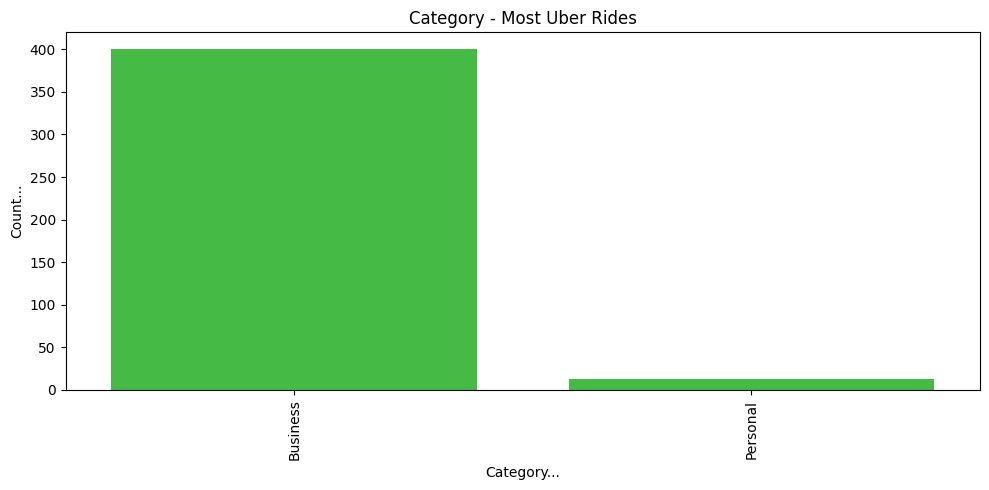

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(x = 'CATEGORY' , data = data , color = 'limegreen')
plt.xticks(rotation = 90)
plt.title('Category - Most Uber Rides')
plt.xlabel('Category...')
plt.ylabel('Count...')
plt.tight_layout()
plt.show()

#    2 . For Which purpose Do People Book Uber Rides The Most?  

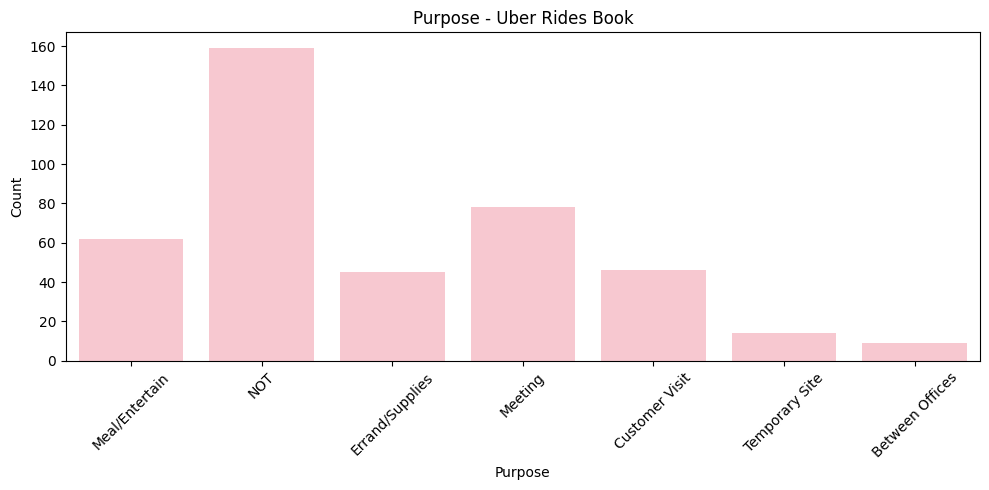

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(x ='PURPOSE' , data = data , color='pink')
plt.xticks(rotation = 45)
plt.title('Purpose - Uber Rides Book')
plt.xlabel('Purpose')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#  3. At What Time Do People Book Cabs The Most From Uber? 

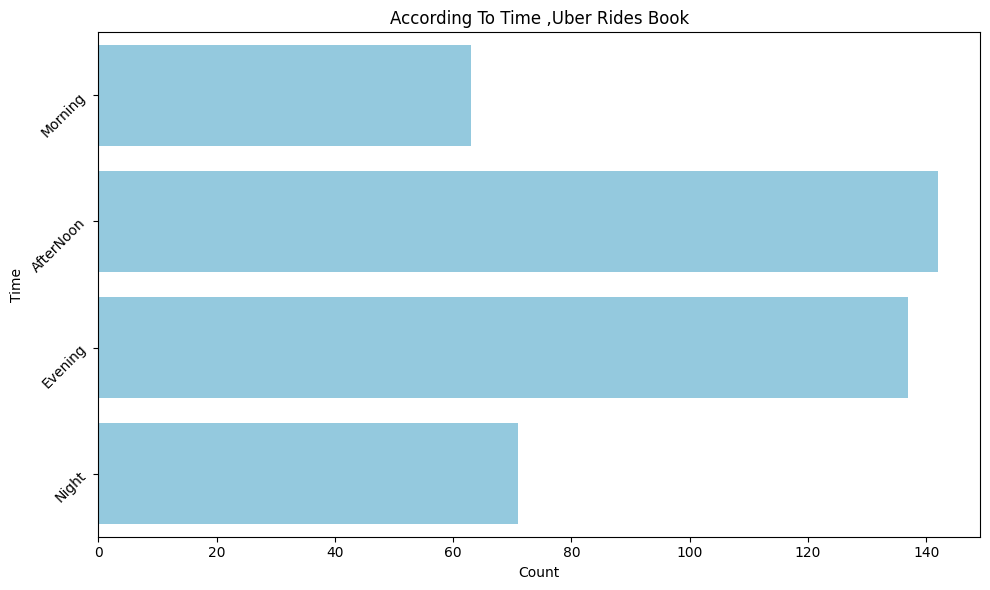

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(y = 'DAY-NIGHT' , data = data , color='skyblue')
plt.yticks(rotation = 45)
plt.title('According To Time ,Uber Rides Book')
plt.xlabel('Count')
plt.ylabel('Time')
plt.tight_layout()
plt.show()

# 4. In Which Months Do People Book Uber Rides Less Frequently? 

In [13]:
# Add New Column Of Month...

data['MONTH'] = pd.DatetimeIndex(data['START_DATE']).month
month_label = {1.0 : 'Jan' , 2.0 : 'Feb' , 3.0 : 'Mar' , 4.0 : 'Apr' , 5.0 : 'May' , 6.0 : 'Jun' , 7.0 : 'Jul' , 8.0 : 'Aug' , 9.0  : 'Sep' , 10.0 : 'Oct' , 11.0 : 'Nov' , 12.0 : 'Dec'}
data['MONTH'] = data.MONTH.map(month_label)
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY-NIGHT,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,Jan
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,Morning,Jan
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night,Jan
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening,Jan
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,AfterNoon,Jan


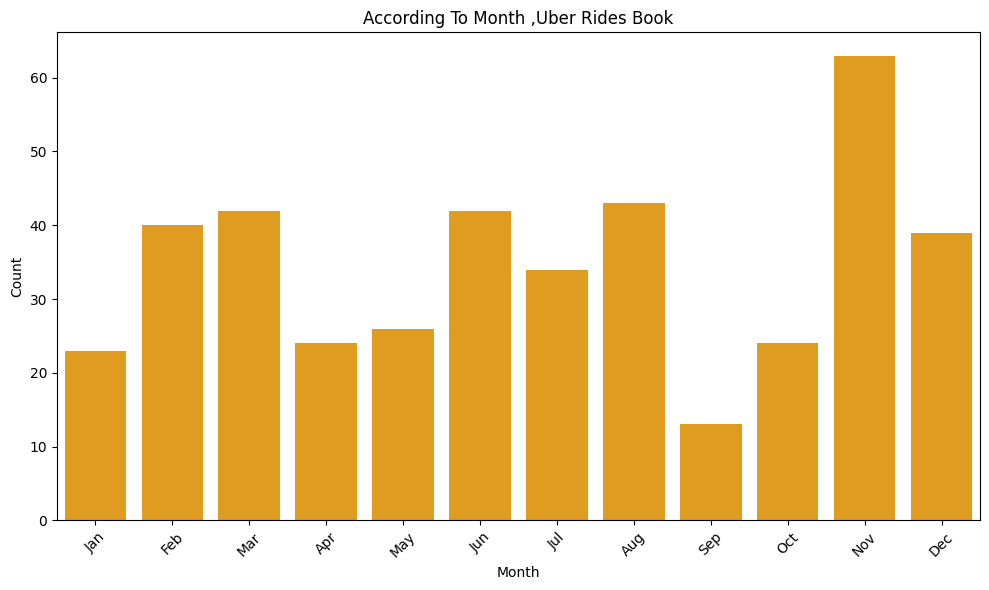

In [30]:
# Visulization .....


plt.figure(figsize=(10,6))
sns.countplot(x = 'MONTH' , data = data , color = 'orange')
plt.xticks(rotation = 45)
plt.title('According To Month ,Uber Rides Book')
plt.xlabel('Month') 
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 5. On Which Days Of The Week Do People Book Uber Rides The Most?  

In [40]:
# Add New Column Of Week...

data['WEEK'] = pd.DatetimeIndex(data['START_DATE']).weekday
month_label = {0 : 'Mon' , 1.0 : 'Tue' , 2.0 : 'Wed' , 3.0 : 'Thu' , 4.0 : 'Fri' , 5.0 : 'Sat' , 6.0  : 'Sun' }
data['WEEK'] = data.WEEK.map(month_label)
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY-NIGHT,MONTH,WEEK
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,NaN,Fri
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,Morning,NaN,Sat
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night,NaN,Sat
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening,NaN,Tue
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,AfterNoon,NaN,Wed


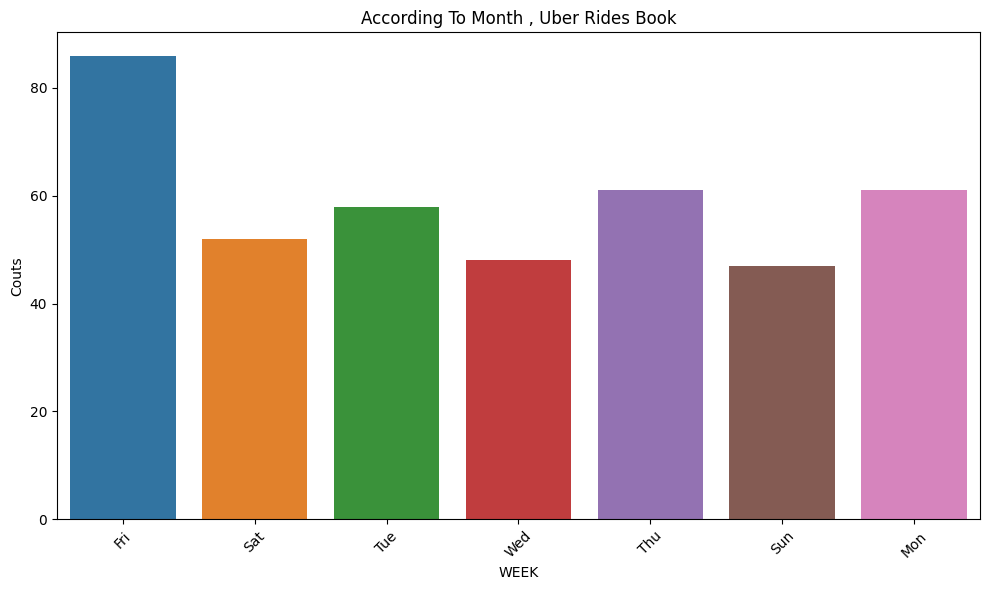

In [45]:
plt.figure(figsize=(10,6))
sns.countplot(x= 'WEEK' , data = data , hue='WEEK' )
plt.xticks(rotation = 45)
plt.title('According To Month , Uber Rides Book')
plt.xlabel('WEEK')
plt.ylabel('Couts')
plt.tight_layout()
plt.show()

#  6. How Many Miles Do People Usually Book A Cab For Through Uber?  

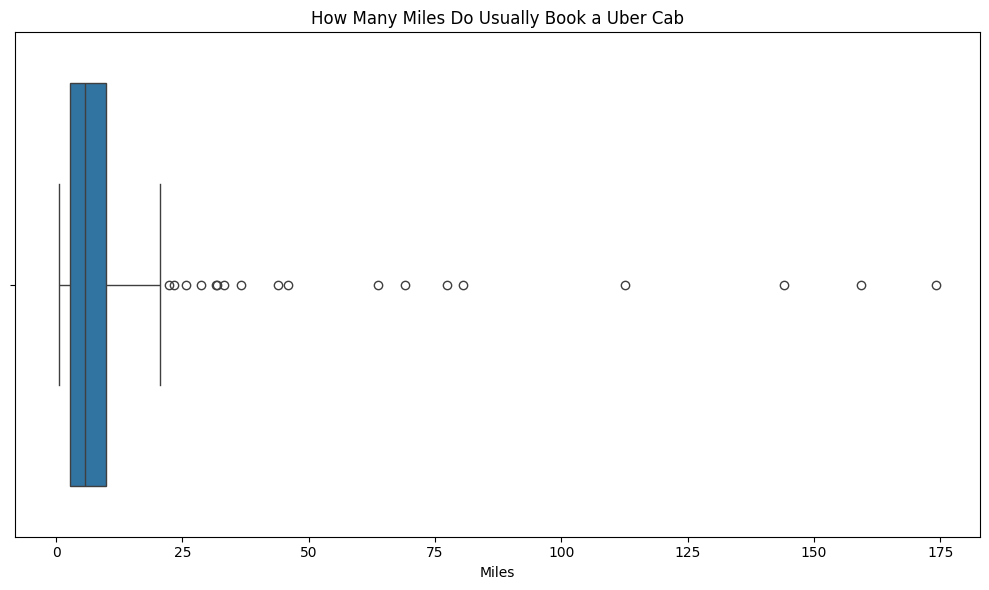

In [56]:
plt.figure(figsize=(10,6))
sns.boxplot(x = 'MILES' , data = data )
plt.title('How Many Miles Do Usually Book a Uber Cab')
plt.xlabel('Miles')
plt.tight_layout()
plt.show()

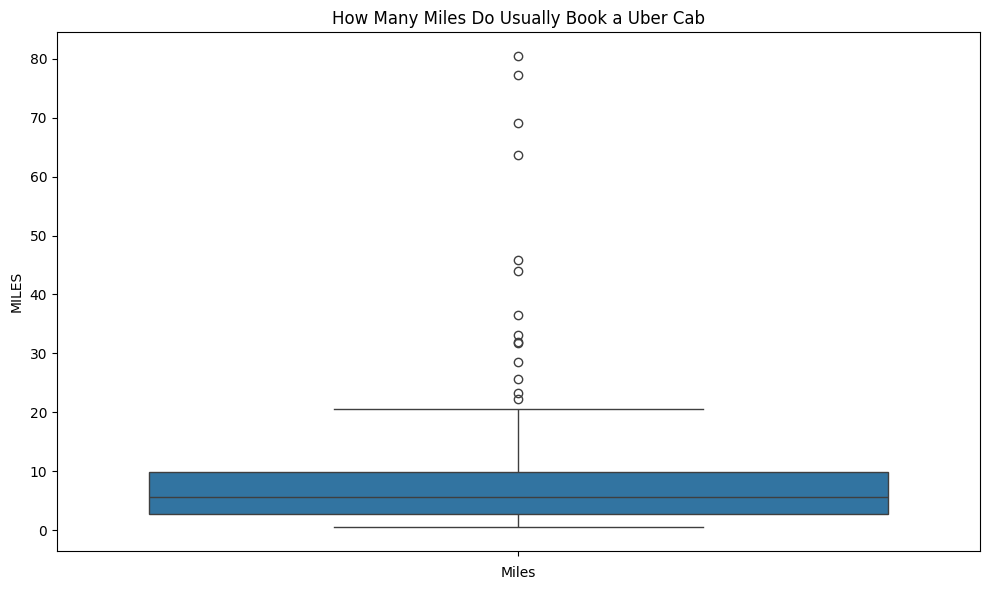

In [61]:
# 2nd Way => 

plt.figure(figsize=(10,6))
sns.boxplot(data[data['MILES'] <100] ['MILES'])
plt.title('How Many Miles Do Usually Book a Uber Cab')
plt.xlabel('Miles')
plt.tight_layout()
plt.show()

C:\Users\legen\AppData\Local\Temp\ipykernel_23916\4037352416.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['MILES'] <100] ['MILES'])


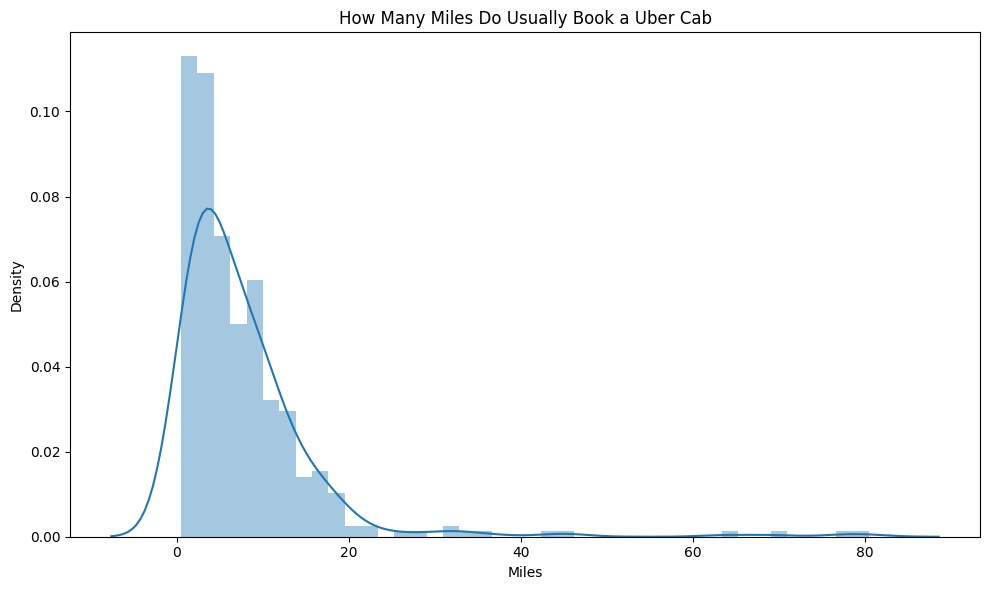

In [66]:
# Densiy Plot ...


plt.figure(figsize=(10,6))
sns.distplot(data[data['MILES'] <100] ['MILES'])
plt.title('How Many Miles Do Usually Book a Uber Cab')
plt.xlabel('Miles')
plt.tight_layout()
plt.show()